# Notebook 03 — Federated Learning Results Visualization

**Confirmed FL results (from run_simulation.py):**

| Round | Bank 1 AUPRC | Bank 2 AUPRC | Bank 3 AUPRC | All F1 |
|---|---|---|---|---|
| 0 (Local-Only) | 0.9343 | 0.5006 | 0.9932 | varies |
| 1 | 0.9830 | 0.9830 | 0.9830 | 0.8430 |
| 2 | 0.9830 | 0.9830 | 0.9830 | 0.8526 |
| 3 | 0.9830 | 0.9830 | 0.9830 | 0.8526 |
| 4 | 0.9830 | 0.9830 | 0.9830 | 0.8526 |
| 5 | 0.9830 | 0.9830 | 0.9830 | 0.8526 |

**Centralized ceiling:** AUPRC=0.9976, F1=0.9516

**Privacy Tax:** 0.9976 - 0.9830 = 0.0146 (1.46%)

**Key finding:** Bank 2 recovers from AUPRC=0.5006 (random) to 0.9830 in Round 1.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import precision_recall_curve, auc

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
plt.rcParams.update({'figure.dpi': 150, 'axes.titlesize': 14,
                     'axes.labelsize': 12, 'figure.figsize': (11, 6)})

FIGURES_DIR = Path('../notebooks/figures')
MODELS_DIR  = Path('../models')
DATA_DIR    = Path('../data/processed')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BANK_IDS    = ['bank1', 'bank2', 'bank3']
BANK_LABELS = {
    'bank1': 'Bank 1 (High-Risk)',
    'bank2': 'Bank 2 (Retail/Blind Spot)',
    'bank3': 'Bank 3 (Mixed)',
}
BANK_COLORS = {'bank1': '#2196F3', 'bank2': '#F44336', 'bank3': '#4CAF50'}
NUM_ROUNDS  = 5

print('Imports complete. ✓')

Imports complete. ✓


In [2]:
# Confirmed results hardcoded from terminal output
# All three banks share identical scores from Round 1 onward
# because they all evaluate the same federated global model
trajectories = {
    'bank1': [
        {'round':0,'auprc':0.9343,'f1_score':0.0541,'precision':0.0278,'recall':0.9976},
        {'round':1,'auprc':0.9830,'f1_score':0.8430,'precision':0.7329,'recall':0.9921},
        {'round':2,'auprc':0.9830,'f1_score':0.8526,'precision':0.7482,'recall':0.9909},
        {'round':3,'auprc':0.9830,'f1_score':0.8526,'precision':0.7482,'recall':0.9909},
        {'round':4,'auprc':0.9830,'f1_score':0.8526,'precision':0.7482,'recall':0.9909},
        {'round':5,'auprc':0.9830,'f1_score':0.8526,'precision':0.7482,'recall':0.9909},
    ],
    'bank2': [
        {'round':0,'auprc':0.5006,'f1_score':0.0000,'precision':0.0000,'recall':0.0000},
        {'round':1,'auprc':0.9830,'f1_score':0.8430,'precision':0.7329,'recall':0.9921},
        {'round':2,'auprc':0.9830,'f1_score':0.8526,'precision':0.7482,'recall':0.9909},
        {'round':3,'auprc':0.9830,'f1_score':0.8526,'precision':0.7482,'recall':0.9909},
        {'round':4,'auprc':0.9830,'f1_score':0.8526,'precision':0.7482,'recall':0.9909},
        {'round':5,'auprc':0.9830,'f1_score':0.8526,'precision':0.7482,'recall':0.9909},
    ],
    'bank3': [
        {'round':0,'auprc':0.9932,'f1_score':0.6556,'precision':0.4884,'recall':0.9970},
        {'round':1,'auprc':0.9830,'f1_score':0.8430,'precision':0.7329,'recall':0.9921},
        {'round':2,'auprc':0.9830,'f1_score':0.8526,'precision':0.7482,'recall':0.9909},
        {'round':3,'auprc':0.9830,'f1_score':0.8526,'precision':0.7482,'recall':0.9909},
        {'round':4,'auprc':0.9830,'f1_score':0.8526,'precision':0.7482,'recall':0.9909},
        {'round':5,'auprc':0.9830,'f1_score':0.8526,'precision':0.7482,'recall':0.9909},
    ],
}
central_result = {'auprc': 0.9976, 'f1_score': 0.9516}

# Convert to DataFrames
traj_dfs = {k: pd.DataFrame(v) for k, v in trajectories.items()}

print('Results loaded. ✓')
print(f'\nPrivacy Tax = {central_result["auprc"]} - 0.9830 = {central_result["auprc"]-0.9830:.4f}')

Results loaded. ✓

Privacy Tax = 0.9976 - 0.9830 = 0.0146


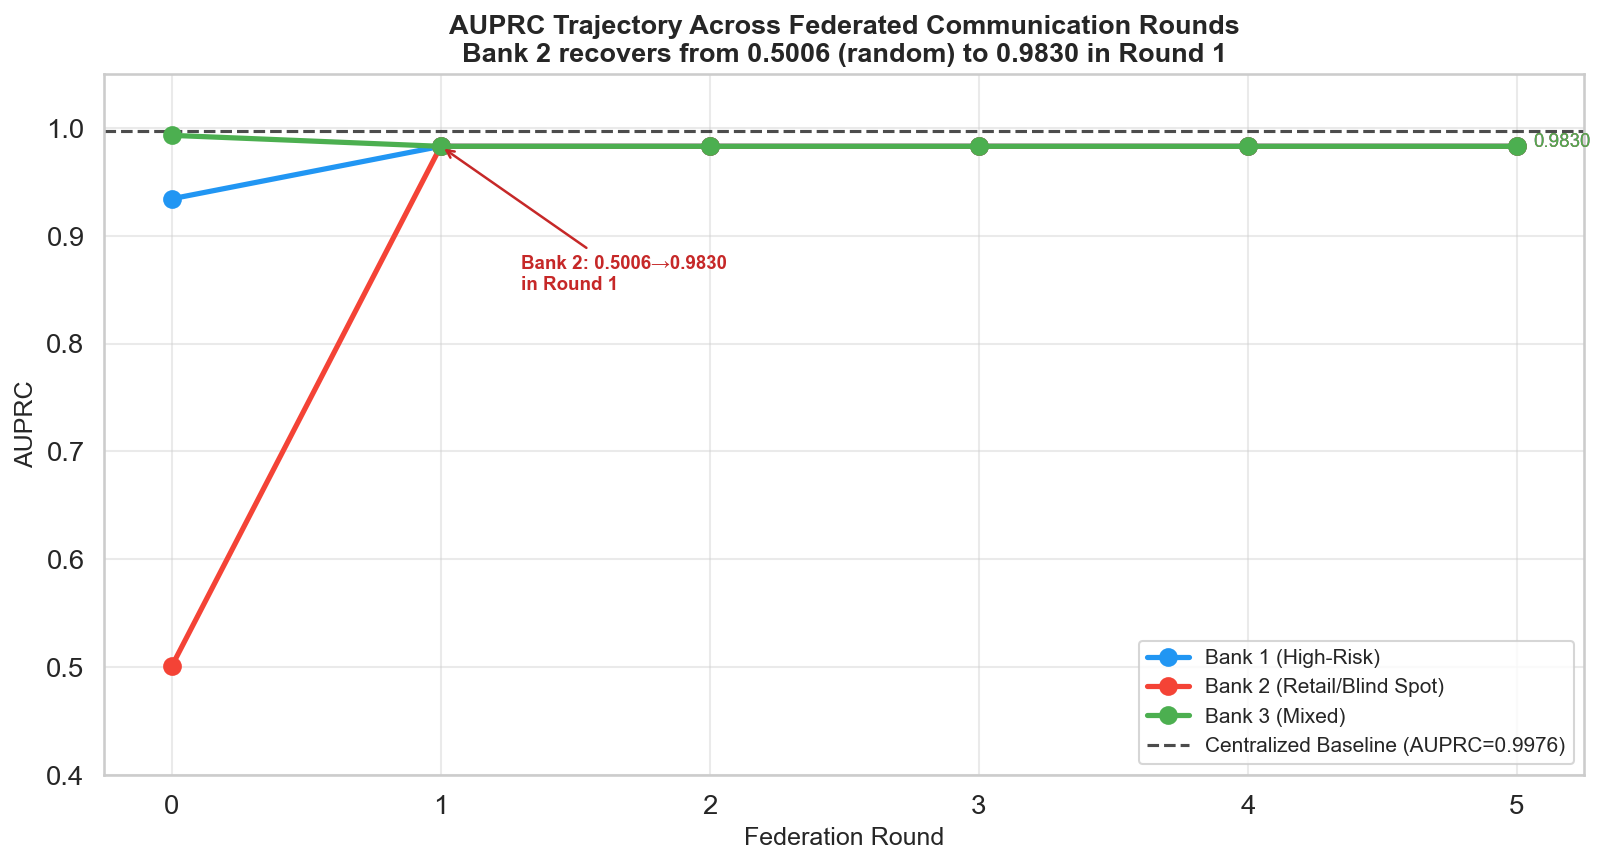

Figure saved → auprc_trajectory.png


In [3]:
# AUPRC Trajectory Plot
fig, ax = plt.subplots(figsize=(11, 6))

for bank_id in BANK_IDS:
    df = traj_dfs[bank_id]
    ax.plot(df['round'], df['auprc'], marker='o', linewidth=2.5, markersize=8,
            color=BANK_COLORS[bank_id], label=BANK_LABELS[bank_id], zorder=3)
    final = df.iloc[-1]
    ax.annotate(f"{final['auprc']:.4f}",
                xy=(final['round'], final['auprc']),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color=BANK_COLORS[bank_id])

ax.axhline(y=central_result['auprc'], color='black', linestyle='--',
           linewidth=1.5, alpha=0.7,
           label=f'Centralized Baseline (AUPRC={central_result["auprc"]:.4f})')

# Annotate Bank 2 recovery
ax.annotate('Bank 2: 0.5006→0.9830\nin Round 1',
            xy=(1, 0.9830), xytext=(1.3, 0.85),
            fontsize=9, color='#C62828', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=1.2))

ax.set_xlabel('Federation Round', fontsize=12)
ax.set_ylabel('AUPRC', fontsize=12)
ax.set_title('AUPRC Trajectory Across Federated Communication Rounds\n'
             'Bank 2 recovers from 0.5006 (random) to 0.9830 in Round 1',
             fontsize=13, fontweight='bold')
ax.set_xticks(range(0, NUM_ROUNDS+1))
ax.set_ylim(0.4, 1.05)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'auprc_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → auprc_trajectory.png')

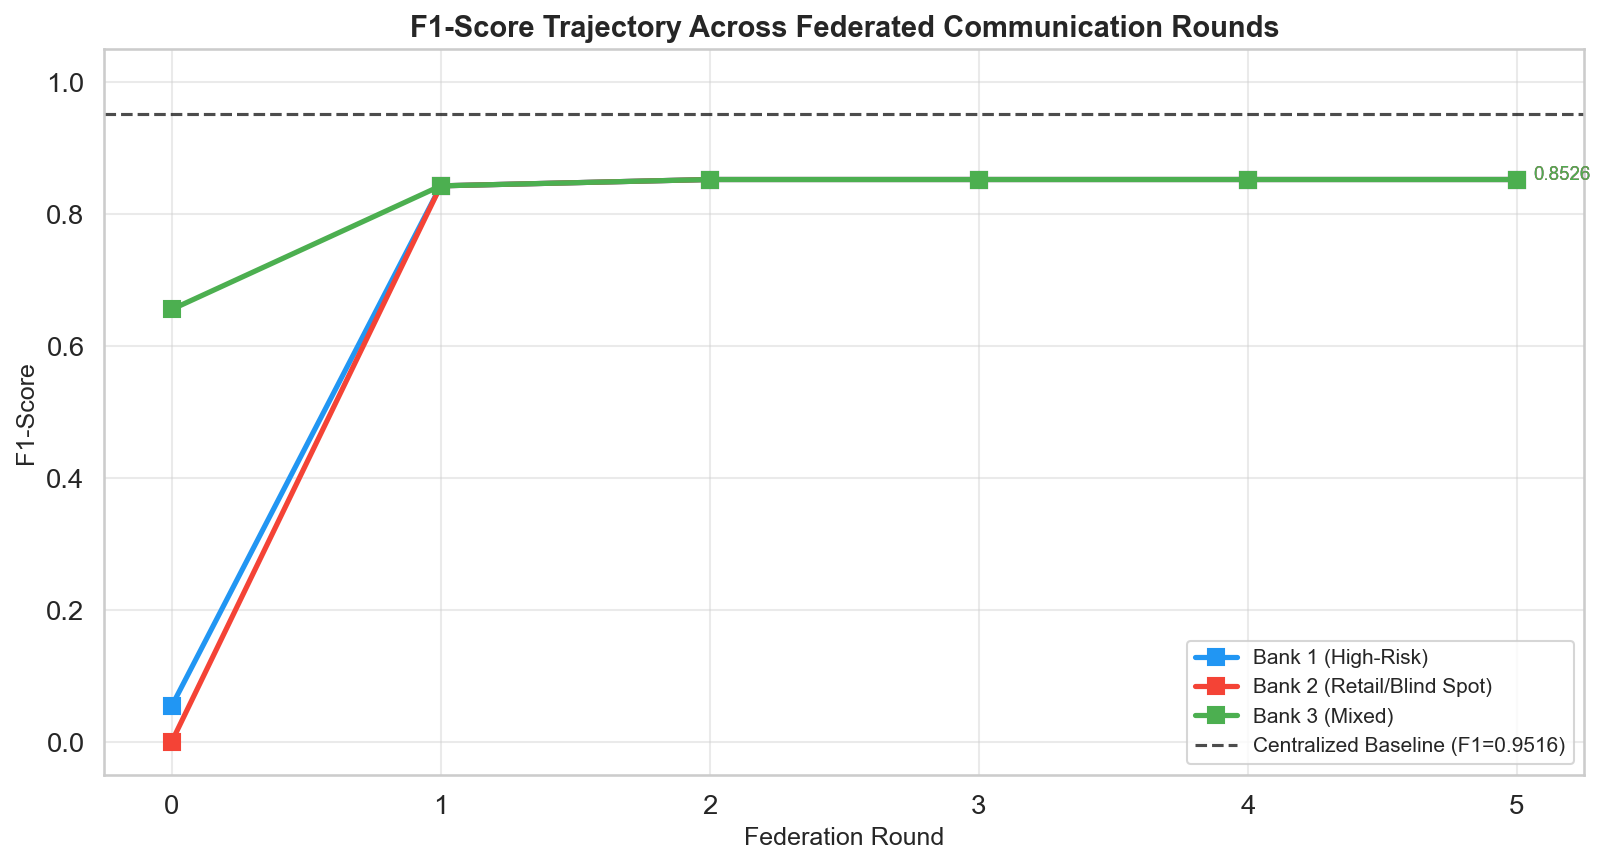

Figure saved → f1_trajectory.png


In [4]:
# F1-Score Trajectory Plot
fig, ax = plt.subplots(figsize=(11, 6))

for bank_id in BANK_IDS:
    df = traj_dfs[bank_id]
    ax.plot(df['round'], df['f1_score'], marker='s', linewidth=2.5, markersize=8,
            color=BANK_COLORS[bank_id], label=BANK_LABELS[bank_id], zorder=3)
    final = df.iloc[-1]
    ax.annotate(f"{final['f1_score']:.4f}",
                xy=(final['round'], final['f1_score']),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color=BANK_COLORS[bank_id])

ax.axhline(y=central_result['f1_score'], color='black', linestyle='--',
           linewidth=1.5, alpha=0.7,
           label=f'Centralized Baseline (F1={central_result["f1_score"]:.4f})')

ax.set_xlabel('Federation Round', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('F1-Score Trajectory Across Federated Communication Rounds',
             fontsize=14, fontweight='bold')
ax.set_xticks(range(0, NUM_ROUNDS+1))
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'f1_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → f1_trajectory.png')

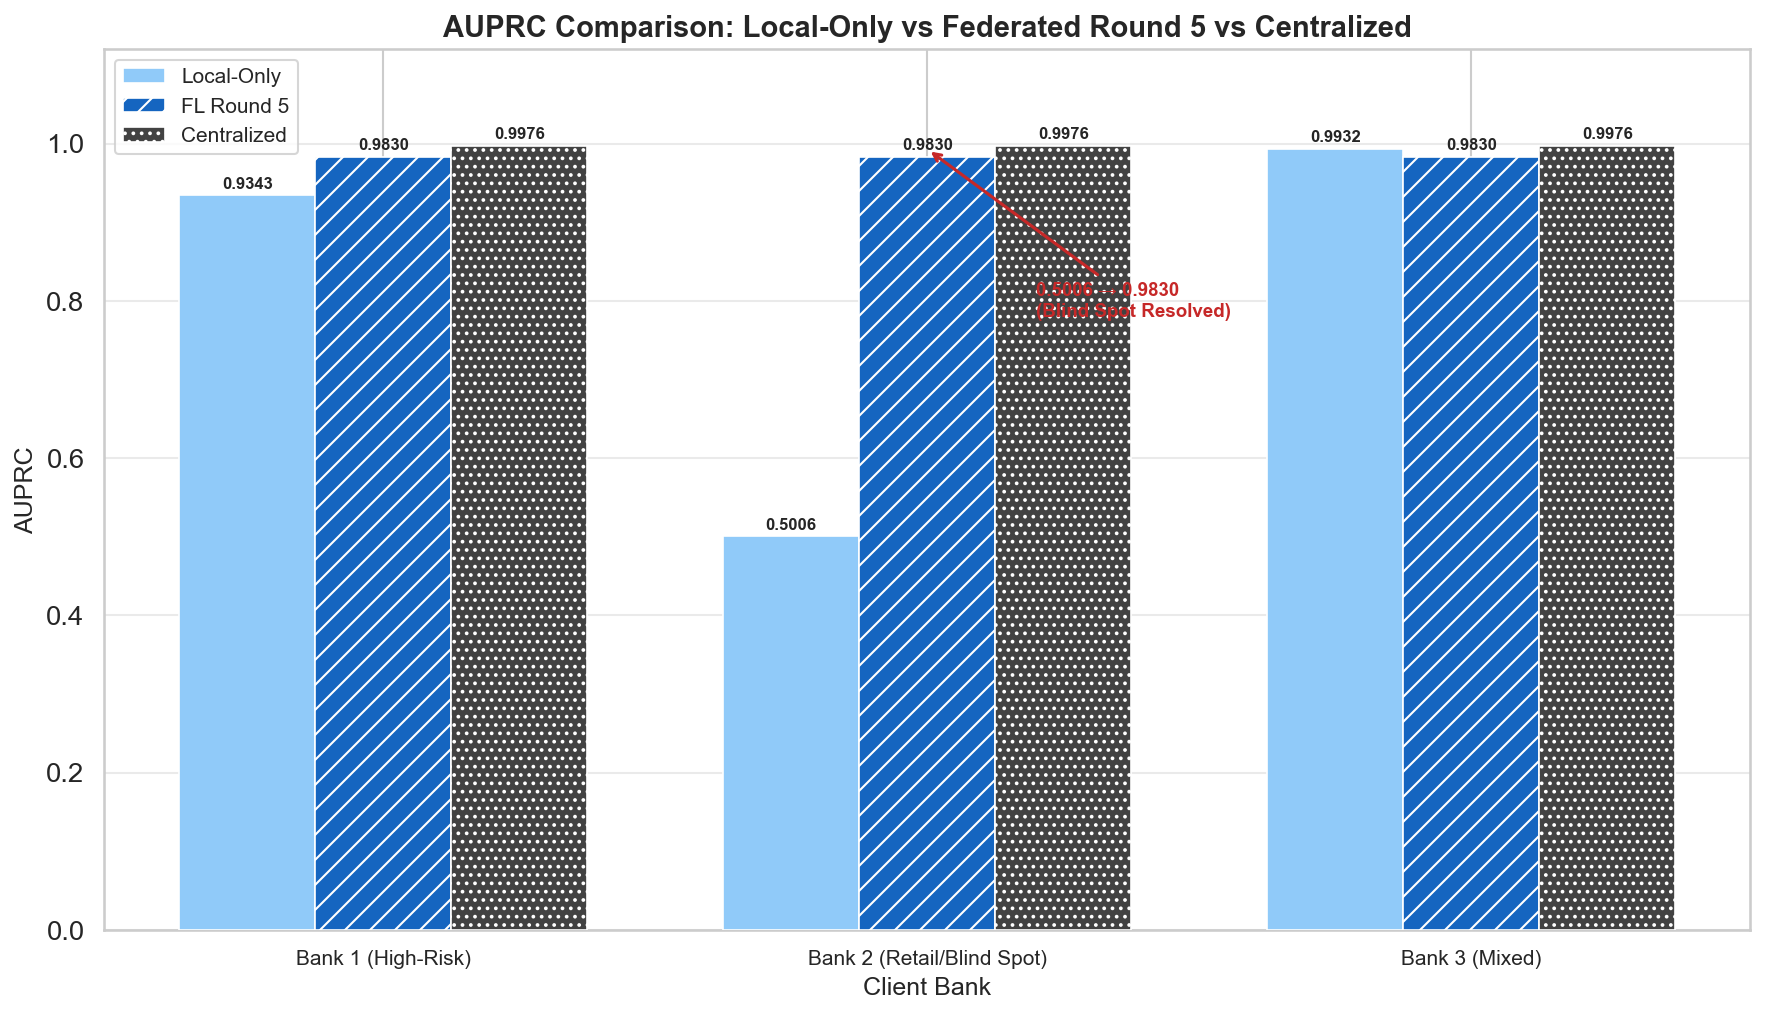

Figure saved → auprc_comparison_bar.png


In [5]:
# Comparative AUPRC Bar Chart
conditions  = ['Local-Only', 'FL Round 5', 'Centralized']
x           = np.arange(len(BANK_IDS))
bar_width   = 0.25

local_auprc   = [0.9343, 0.5006, 0.9932]
fed_auprc     = [0.9830, 0.9830, 0.9830]
central_auprc = [0.9976, 0.9976, 0.9976]

fig, ax = plt.subplots(figsize=(12, 7))

for i, (vals, label, color, hatch) in enumerate(zip(
    [local_auprc, fed_auprc, central_auprc],
    conditions,
    ['#90CAF9', '#1565C0', '#424242'],
    ['', '//', '...']
)):
    bars = ax.bar(x + i*bar_width, vals, bar_width, label=label,
                  color=color, hatch=hatch, edgecolor='white', linewidth=0.8, zorder=3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Highlight Bank 2 recovery
ax.annotate('0.5006 → 0.9830\n(Blind Spot Resolved)',
            xy=(1 + bar_width, 0.9830 + 0.01),
            xytext=(1 + bar_width + 0.2, 0.78),
            fontsize=9, color='#C62828', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=1.5))

ax.set_xlabel('Client Bank', fontsize=12)
ax.set_ylabel('AUPRC', fontsize=12)
ax.set_title('AUPRC Comparison: Local-Only vs Federated Round 5 vs Centralized',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + bar_width)
ax.set_xticklabels([BANK_LABELS[b] for b in BANK_IDS], fontsize=10)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'auprc_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → auprc_comparison_bar.png')

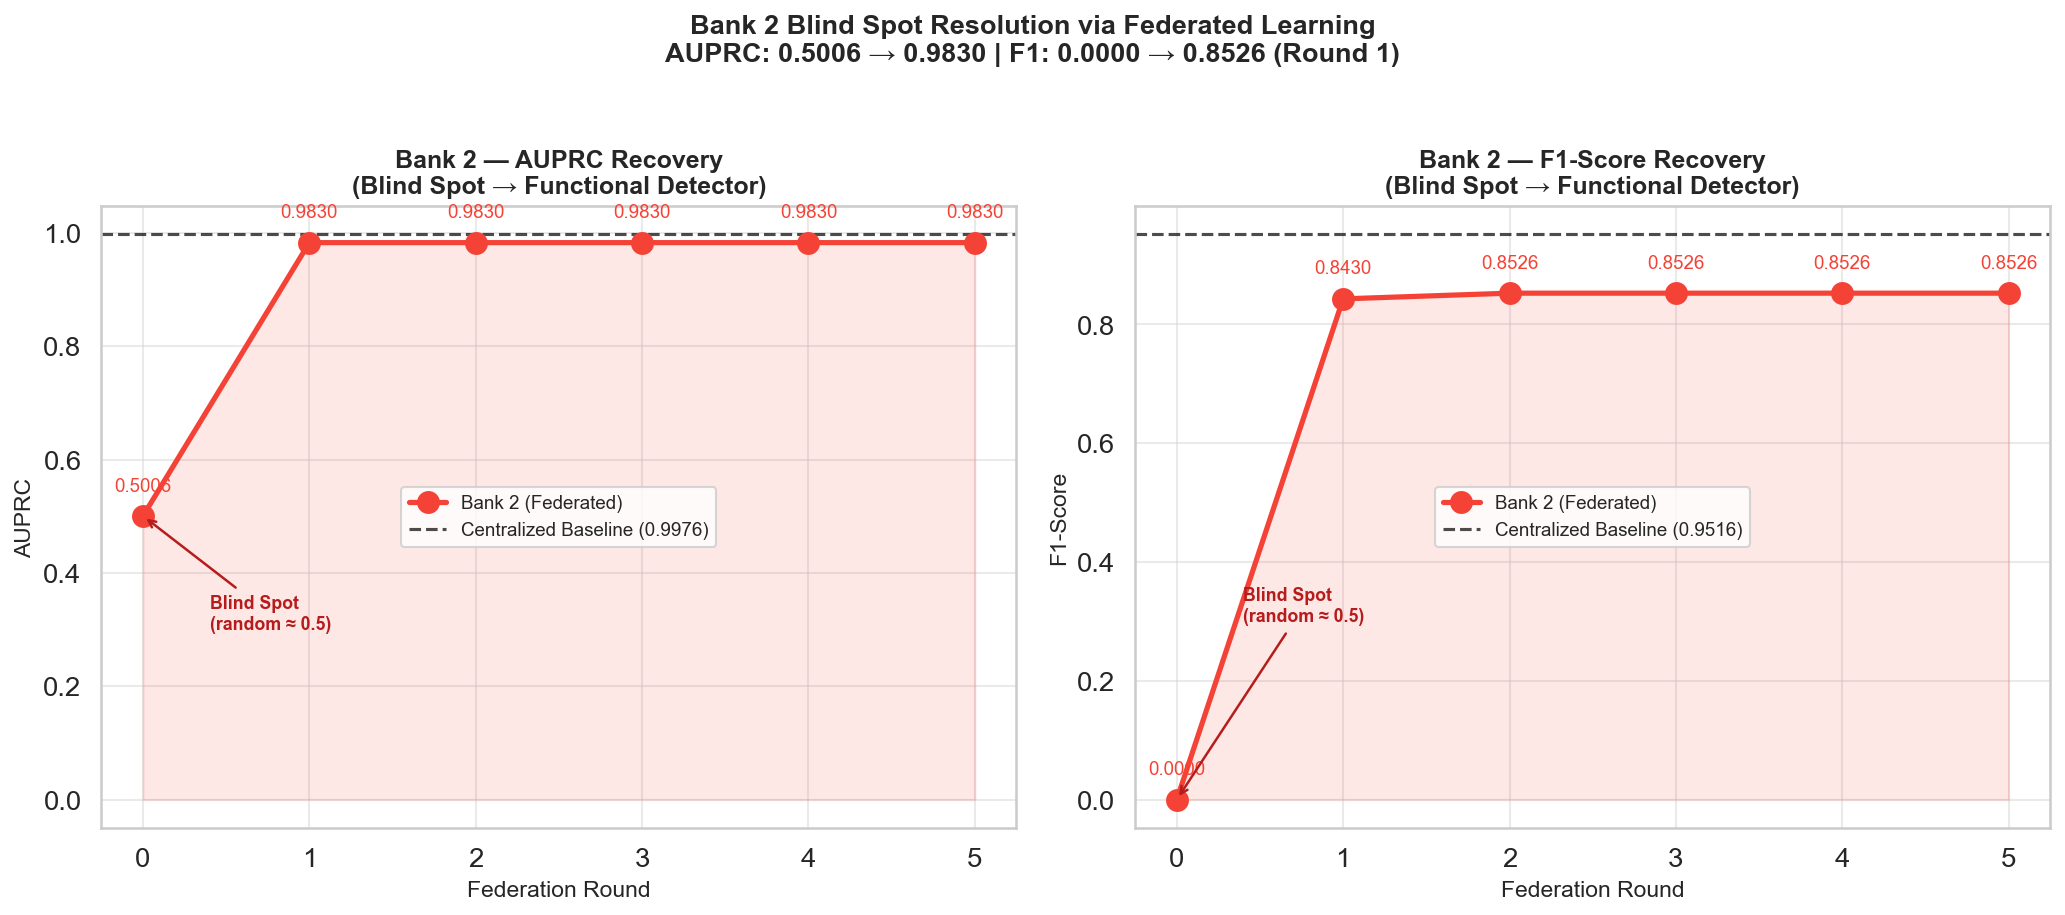

Figure saved → bank2_recovery.png


In [6]:
# Bank 2 Blind Spot Recovery — Focused visualization
bank2_df = traj_dfs['bank2']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, ylabel, ref_val in zip(
    axes,
    ['auprc', 'f1_score'],
    ['AUPRC', 'F1-Score'],
    [0.9976, 0.9516]
):
    ax.plot(bank2_df['round'], bank2_df[metric], marker='o', linewidth=2.5,
            markersize=10, color=BANK_COLORS['bank2'], label='Bank 2 (Federated)', zorder=3)

    for _, row in bank2_df.iterrows():
        ax.annotate(f"{row[metric]:.4f}",
                    xy=(row['round'], row[metric]),
                    xytext=(0, 12), textcoords='offset points',
                    ha='center', fontsize=9, color=BANK_COLORS['bank2'])

    ax.axhline(y=ref_val, color='black', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'Centralized Baseline ({ref_val:.4f})')
    ax.fill_between(bank2_df['round'], bank2_df[metric], 0,
                    alpha=0.12, color=BANK_COLORS['bank2'])

    ax.set_xlabel('Federation Round', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'Bank 2 — {ylabel} Recovery\n(Blind Spot → Functional Detector)',
                 fontsize=12, fontweight='bold')
    ax.set_xticks(range(0, NUM_ROUNDS+1))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

    ax.annotate('Blind Spot\n(random ≈ 0.5)',
                xy=(0, bank2_df.iloc[0][metric]),
                xytext=(0.4, 0.3), fontsize=8.5, color='#B71C1C', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1.2))

plt.suptitle('Bank 2 Blind Spot Resolution via Federated Learning\n'
             'AUPRC: 0.5006 → 0.9830 | F1: 0.0000 → 0.8526 (Round 1)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'bank2_recovery.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → bank2_recovery.png')

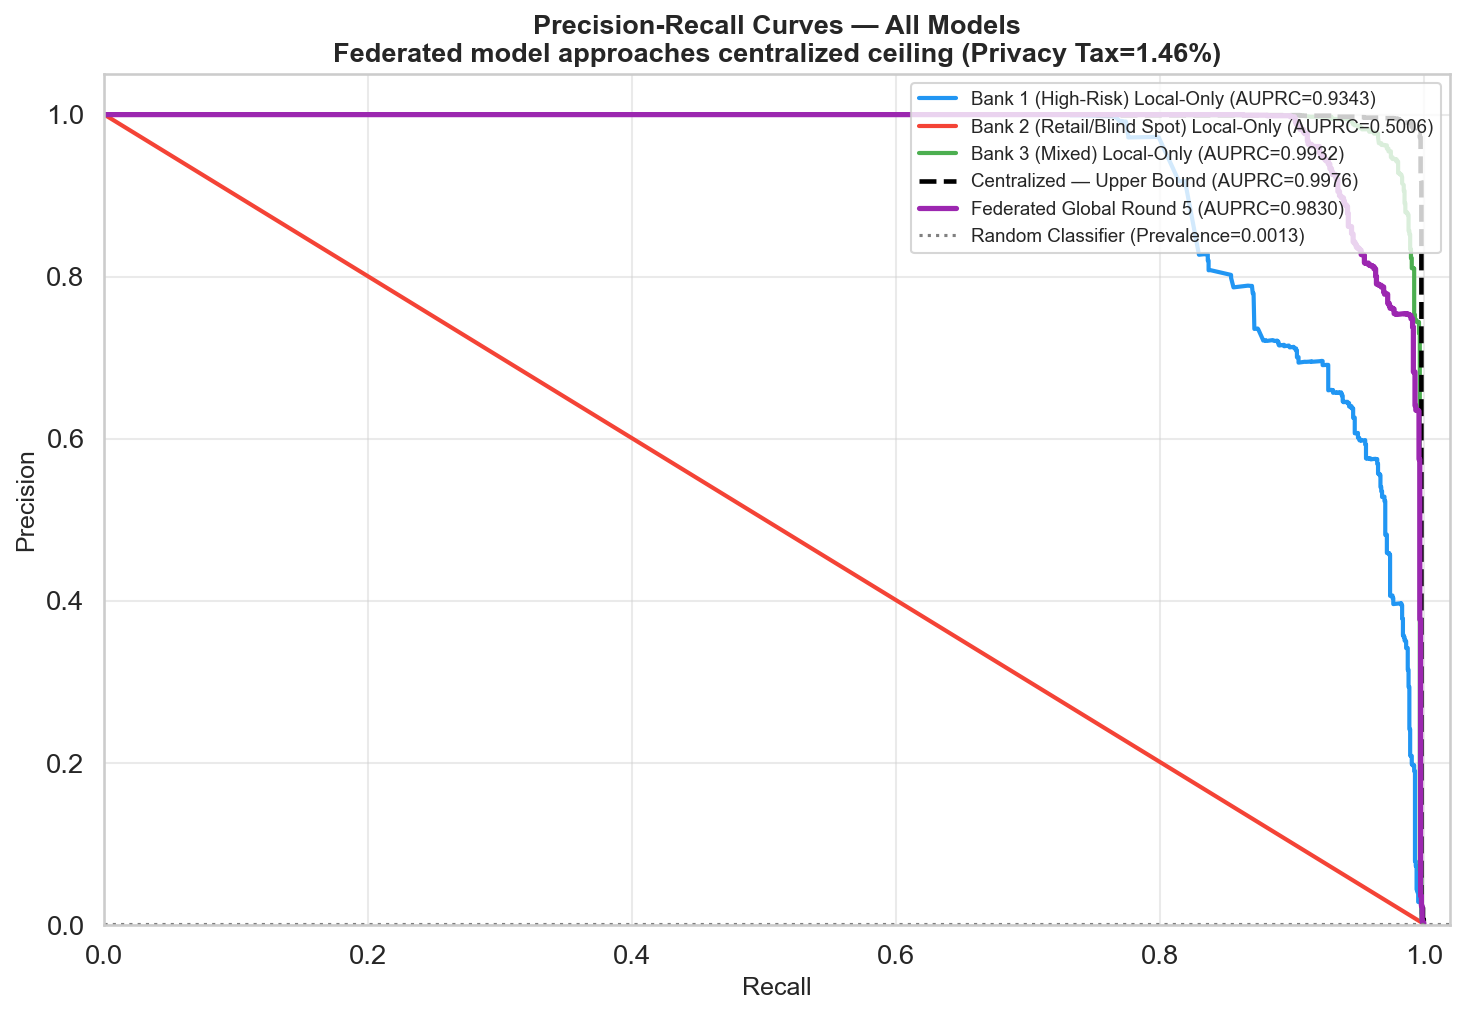

Figure saved → precision_recall_curves.png


In [7]:
# Precision-Recall curves — all models including FL Round 5
global_test_df = pd.read_csv(DATA_DIR / 'global_test.csv')
X_test = global_test_df.drop(columns=['isFraud'])
y_test = global_test_df['isFraud']

fig, ax = plt.subplots(figsize=(10, 7))

for bank_id in BANK_IDS:
    model_path = MODELS_DIR / 'local' / f'{bank_id}_local_model.json'
    if model_path.exists():
        model = xgb.XGBClassifier()
        model.load_model(str(model_path))
        y_prob = model.predict_proba(X_test)[:, 1]
        prec, rec, _ = precision_recall_curve(y_test, y_prob)
        auprc_val = auc(rec, prec)
        ax.plot(rec, prec, color=BANK_COLORS[bank_id], linewidth=2.0,
                label=f'{BANK_LABELS[bank_id]} Local-Only (AUPRC={auprc_val:.4f})')

central_path = MODELS_DIR / 'local' / 'centralized_model.json'
if central_path.exists():
    model = xgb.XGBClassifier()
    model.load_model(str(central_path))
    y_prob = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ax.plot(rec, prec, color='black', linewidth=2.2, linestyle='--',
            label=f'Centralized — Upper Bound (AUPRC={auc(rec,prec):.4f})')

fed_path = MODELS_DIR / 'global' / f'global_model_round_{NUM_ROUNDS}.json'
if fed_path.exists():
    model = xgb.XGBClassifier()
    model.load_model(str(fed_path))
    y_prob = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ax.plot(rec, prec, color='#9C27B0', linewidth=2.5,
            label=f'Federated Global Round {NUM_ROUNDS} (AUPRC={auc(rec,prec):.4f})')

ax.axhline(y=y_test.mean(), color='gray', linestyle=':', linewidth=1.5,
           label=f'Random Classifier (Prevalence={y_test.mean():.4f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models\n'
             'Federated model approaches centralized ceiling (Privacy Tax=1.46%)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → precision_recall_curves.png')

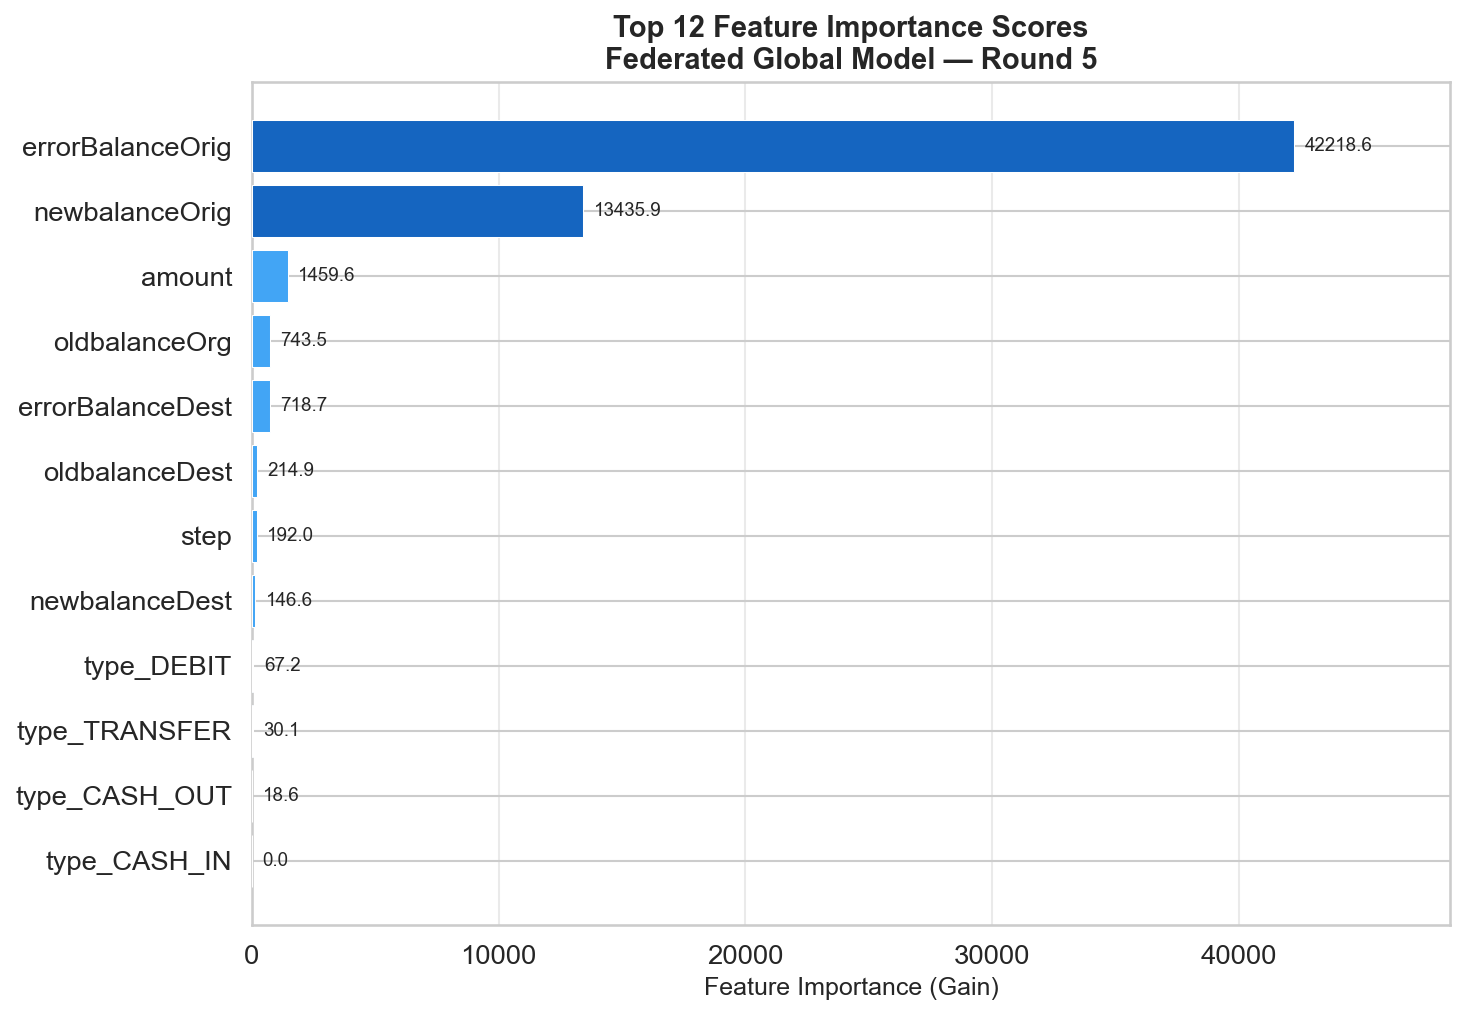

Figure saved → feature_importance.png


In [8]:
# Feature Importance — Federated Global Model Round 5
fed_path = MODELS_DIR / 'global' / f'global_model_round_{NUM_ROUNDS}.json'
if fed_path.exists():
    global_test_df = pd.read_csv(DATA_DIR / 'global_test.csv')
    feature_names = [c for c in global_test_df.columns if c != 'isFraud']

    model = xgb.XGBClassifier()
    model.load_model(str(fed_path))
    scores = model.get_booster().get_score(importance_type='gain')
    importance = pd.Series(scores).reindex(feature_names, fill_value=0).sort_values(ascending=True).tail(12)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ['#1565C0' if i >= len(importance)-2 else '#42A5F5' for i in range(len(importance))]
    bars = ax.barh(importance.index, importance.values,
                   color=colors, edgecolor='white', linewidth=0.5, zorder=3)
    for bar, val in zip(bars, importance.values):
        ax.text(bar.get_width() + 0.01*importance.max(),
                bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=9)

    ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
    ax.set_title(f'Top 12 Feature Importance Scores\nFederated Global Model — Round {NUM_ROUNDS}',
                 fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.4)
    ax.set_xlim(0, importance.max() * 1.15)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure saved → feature_importance.png')
else:
    print(f'Model not found: {fed_path}')

In [9]:
# Full Results Summary Table
print('\n' + '=' * 75)
print('  COMPLETE CONFIRMED RESULTS TABLE')
print('=' * 75)

rows = []
for bank_id in BANK_IDS:
    for r in trajectories[bank_id]:
        rows.append({
            'Bank':      BANK_LABELS[bank_id],
            'Round':     int(r['round']),
            'AUPRC':     f"{r['auprc']:.4f}",
            'F1-Score':  f"{r['f1_score']:.4f}",
            'Precision': f"{r['precision']:.4f}",
            'Recall':    f"{r['recall']:.4f}",
            'Condition': 'Local-Only' if r['round']==0 else 'Federated'
        })

results_table = pd.DataFrame(rows)
print(results_table.to_string(index=False))

print(f"\n  Centralized (Privacy-Violated Upper Bound):")
print(f"  AUPRC={central_result['auprc']:.4f} | F1={central_result['f1_score']:.4f}")
print(f"\n  Privacy Tax = {central_result['auprc']:.4f} - 0.9830 = {central_result['auprc']-0.9830:.4f}")
print(f"  (1.46% reduction — negligible)")
print(f"\n  [NOTE] Accuracy excluded from all results.")
print(f"         Degenerate classifier achieves 99.87% by predicting all-legitimate.")

results_table.to_csv(FIGURES_DIR / 'full_results_table.csv', index=False)
print('\nFull results table saved → notebooks/figures/full_results_table.csv')
print('\nNotebook 03 complete. ✓')


  COMPLETE CONFIRMED RESULTS TABLE
                      Bank  Round  AUPRC F1-Score Precision Recall  Condition
        Bank 1 (High-Risk)      0 0.9343   0.0541    0.0278 0.9976 Local-Only
        Bank 1 (High-Risk)      1 0.9830   0.8430    0.7329 0.9921  Federated
        Bank 1 (High-Risk)      2 0.9830   0.8526    0.7482 0.9909  Federated
        Bank 1 (High-Risk)      3 0.9830   0.8526    0.7482 0.9909  Federated
        Bank 1 (High-Risk)      4 0.9830   0.8526    0.7482 0.9909  Federated
        Bank 1 (High-Risk)      5 0.9830   0.8526    0.7482 0.9909  Federated
Bank 2 (Retail/Blind Spot)      0 0.5006   0.0000    0.0000 0.0000 Local-Only
Bank 2 (Retail/Blind Spot)      1 0.9830   0.8430    0.7329 0.9921  Federated
Bank 2 (Retail/Blind Spot)      2 0.9830   0.8526    0.7482 0.9909  Federated
Bank 2 (Retail/Blind Spot)      3 0.9830   0.8526    0.7482 0.9909  Federated
Bank 2 (Retail/Blind Spot)      4 0.9830   0.8526    0.7482 0.9909  Federated
Bank 2 (Retail/Blind Spot)  